In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "../data/"

def parse_dates(series):
    return pd.to_datetime(series.str.strip('"'), utc=True)

# Cargar los datos necesarios para este análisis
users = pd.read_csv(DATA_PATH + "users.csv")
subs = pd.read_csv(DATA_PATH + "stripe_subscriptions.csv")
test_sessions = pd.read_csv(DATA_PATH + "test_sessions.csv", low_memory=False, sep=';')
flashcard_sessions = pd.read_csv(DATA_PATH + "flashcards_sessions.csv", low_memory=False)
chat_messages = pd.read_csv(DATA_PATH + "chat_messages.csv", low_memory=False, sep=';')
ai_spans = pd.read_csv(DATA_PATH + "ai_spans.csv", low_memory=False)
traces = pd.read_csv(DATA_PATH + "traces.csv", low_memory=False, sep=';')
answer_tries = pd.read_csv(DATA_PATH + "answer_tries.csv", low_memory=False)
folders = pd.read_csv(DATA_PATH + "folders.csv", low_memory=False)
# Cargar tablas necesarias para linkear chat con usuarios
chat_conversations = pd.read_csv(DATA_PATH + "chat_conversation.csv", low_memory=False)
chat_relations = pd.read_csv(DATA_PATH + "chat_messages_chat_relation.csv", low_memory=False)

# Parsear fechas
users['created_at'] = parse_dates(users['created_at'])
users['subscription_created_at'] = parse_dates(users['subscription_created_at'])
subs['created'] = parse_dates(subs['created'])
test_sessions['created_at'] = parse_dates(test_sessions['created_at'])
flashcard_sessions['created_at'] = parse_dates(flashcard_sessions['created_at'])
chat_messages['created_at'] = parse_dates(chat_messages['created_at'])
ai_spans['created_at'] = parse_dates(ai_spans['created_at'])
traces['created_at'] = parse_dates(traces['created_at'])

print("✅ Todos los datos cargados")
print(f"Usuarios: {len(users):,}")
print(f"Suscripciones: {len(subs):,}")
print(f"Sesiones de test: {len(test_sessions):,}")
print(f"Sesiones flashcard: {len(flashcard_sessions):,}")
print(f"Mensajes chat: {len(chat_messages):,}")
print(f"AI spans: {len(ai_spans):,}")
print(f"Traces: {len(traces):,}")
print(f"Answer tries: {len(answer_tries):,}")
print(f"Folders: {len(folders):,}")
print(f"Conversaciones chat: {len(chat_conversations):,}")
print(f"Relaciones mensaje-conversación: {len(chat_relations):,}")

print(f"\nColumnas chat_conversations: {list(chat_conversations.columns)}")
print(f"Columnas chat_relations: {list(chat_relations.columns)}")

✅ Todos los datos cargados
Usuarios: 32,636
Suscripciones: 627
Sesiones de test: 212,387
Sesiones flashcard: 14,411
Mensajes chat: 48,000
AI spans: 269,383
Traces: 112,353
Answer tries: 3,513,744
Folders: 3,966
Conversaciones chat: 7,136
Relaciones mensaje-conversación: 47,991

Columnas chat_conversations: ['id', 'user_id', 'created_at', 'updated_at']
Columnas chat_relations: ['conversation_id', 'message_id']


## ⚠️ Contexto importante para la interpretación

El orden de lanzamiento de funcionalidades en Proxus fue:
1. **Tests** — desde el inicio de la plataforma (mayo 2025)
2. **Chat IA** — lanzado el 5 de noviembre de 2025
3. **Flashcards** — lanzadas el 3 de enero de 2026
4. **Folders** — fecha pendiente de confirmar con Dani

Esto significa que la diferencia de volumen entre funcionalidades 
NO refleja únicamente preferencia de los usuarios — también refleja 
el tiempo que lleva disponible cada feature.

**Implicación para el análisis:** 
- Comparativas de uso entre features → filtrar desde el 3 de enero 
  (fecha en que todas las features principales estaban disponibles)
- Análisis de conversión → tener en cuenta qué features existían 
  cuando cada usuario se registró
- Los 32.017 usuarios free registrados antes de enero no tuvieron 
  acceso a flashcards hasta el 3 de enero

In [3]:
# Definir los tres grupos clave
pagadores = users[users['subscription_type'] != 'free'].copy()
churned = users[
    (users['subscription_type'] == 'free') & 
    (users['stripe_customer_id'].notna())
].copy()
free_puro = users[
    (users['subscription_type'] == 'free') & 
    (users['stripe_customer_id'].isna())
].copy()

print("=== SEGMENTACIÓN DE USUARIOS ===")
print(f"Usuarios de pago activos: {len(pagadores):,}")
print(f"Usuarios que pagaron y cancelaron (churned): {len(churned):,}")
print(f"Usuarios free puros (nunca pagaron): {len(free_puro):,}")
print(f"Total: {len(pagadores) + len(churned) + len(free_puro):,}")

=== SEGMENTACIÓN DE USUARIOS ===
Usuarios de pago activos: 516
Usuarios que pagaron y cancelaron (churned): 103
Usuarios free puros (nunca pagaron): 32,017
Total: 32,636


In [4]:
# Construir perfil de uso por usuario
print("Calculando métricas de uso por usuario...")

# 1. Sesiones de test por usuario
test_uso = test_sessions.groupby('user_id').agg(
    num_test_sessions=('id', 'count'),
    test_sessions_completadas=('finished', 'sum'),
    score_medio=('score', 'mean'),
    preguntas_totales=('total_questions', 'sum')
).reset_index()

# 2. Sesiones de flashcard por usuario
flash_uso = flashcard_sessions.groupby('user_id').agg(
    num_flash_sessions=('id', 'count'),
    flash_sessions_completadas=('finished', 'sum')
).reset_index()

# 3. Mensajes de chat por usuario
chat_uso = chat_messages.merge(
    chat_relations, left_on='id', right_on='message_id', how='left'
).merge(
    chat_conversations[['id', 'user_id']], left_on='conversation_id', right_on='id', how='left'
)
chat_uso = chat_uso[chat_uso['role'] == 'user'].groupby('user_id').agg(
    num_chat_messages=('message_id', 'count')
).reset_index()

# 4. Carpetas creadas por usuario
folders_uso = folders.groupby('user_id').agg(
    num_folders=('id', 'count')
).reset_index()

# Construir perfil base
perfil = users[['id', 'subscription_type', 'stripe_customer_id',
                'xp', 'level', 'actual_streak', 'best_streak',
                'created_at', 'subscription_created_at']].copy()

# Merges limpios — renombrar user_id antes de unir para evitar duplicados
perfil = perfil.merge(test_uso.rename(columns={'user_id': 'id'}), on='id', how='left')
perfil = perfil.merge(flash_uso.rename(columns={'user_id': 'id'}), on='id', how='left')
perfil = perfil.merge(chat_uso.rename(columns={'user_id': 'id'}), on='id', how='left')
perfil = perfil.merge(folders_uso.rename(columns={'user_id': 'id'}), on='id', how='left')

# Rellenar NaN con 0
cols_uso = ['num_test_sessions', 'test_sessions_completadas', 'score_medio',
            'preguntas_totales', 'num_flash_sessions', 'flash_sessions_completadas',
            'num_chat_messages', 'num_folders']
perfil[cols_uso] = perfil[cols_uso].fillna(0)

# Añadir segmento
def segmento(row):
    if row['subscription_type'] != 'free':
        return 'pagador'
    elif pd.notna(row['stripe_customer_id']):
        return 'churned'
    else:
        return 'free_puro'

perfil['segmento'] = perfil.apply(segmento, axis=1)

print("✅ Perfil de uso construido")
print(perfil['segmento'].value_counts())

Calculando métricas de uso por usuario...
✅ Perfil de uso construido
segmento
free_puro    32017
pagador        516
churned        103
Name: count, dtype: int64


In [5]:
# ============================================
# ESTADÍSTICAS BASE PARA G3
# ============================================

metricas_g3 = ['preguntas_totales', 'num_chat_messages', 'num_test_sessions']

medianas = perfil.groupby('segmento')[metricas_g3].median()
print("=== MEDIANAS POR SEGMENTO ===")
print(medianas.round(1))

=== MEDIANAS POR SEGMENTO ===
           preguntas_totales  num_chat_messages  num_test_sessions
segmento                                                          
churned                660.0                3.0               24.0
free_puro               25.0                0.0                1.0
pagador                577.0                0.0               23.0


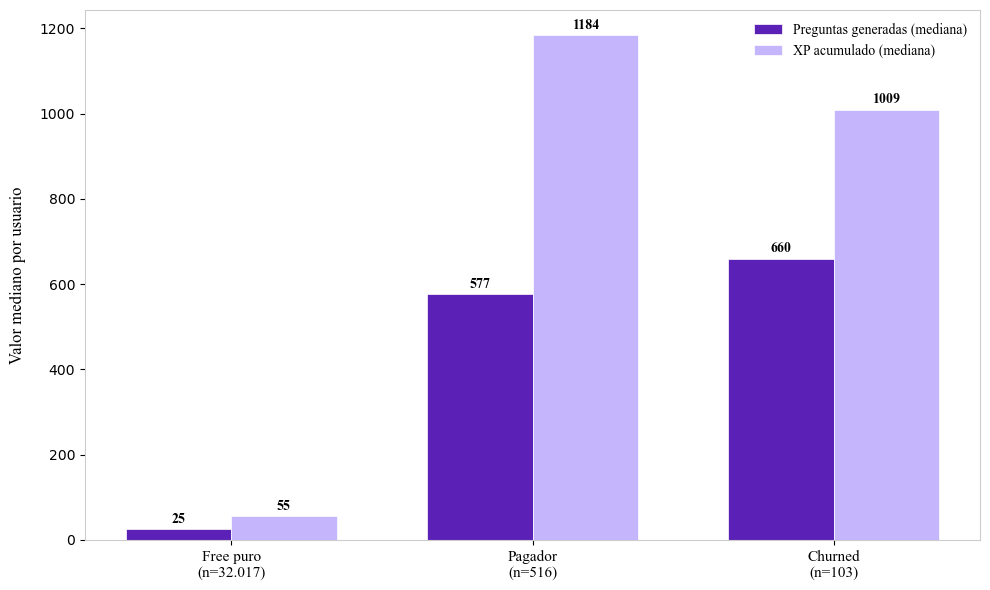

✅ G3 guardado en outputs/


In [6]:
# ============================================
# G3 — Comparativa de uso por segmento
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# Datos
segmentos = ['Free puro\n(n=32.017)', 'Pagador\n(n=516)', 'Churned\n(n=103)']
preguntas = [25.0, 577.0, 660.0]
xp = [55.0, 1184.0, 1009.0]

x = np.arange(len(segmentos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras1 = ax.bar(x - ancho/2, preguntas, ancho,
                 label='Preguntas generadas (mediana)',
                 color='#5B21B6', edgecolor='white', linewidth=0.5)
barras2 = ax.bar(x + ancho/2, xp, ancho,
                 label='XP acumulado (mediana)',
                 color='#C4B5FD', edgecolor='white', linewidth=0.5)

for bar in barras1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=10,
            fontfamily='Times New Roman', fontweight='bold')

for bar in barras2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=10,
            fontfamily='Times New Roman', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(segmentos, fontsize=11, fontfamily='Times New Roman')
ax.set_ylabel('Valor mediano por usuario', fontsize=12,
              fontfamily='Times New Roman', labelpad=10)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=10, framealpha=0,
          prop={'family': 'Times New Roman'})

for spine in ['left', 'bottom', 'top', 'right']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#cccccc')
    ax.spines[spine].set_linewidth(0.8)

plt.tight_layout()
plt.savefig('../outputs/G3_uso_por_segmento.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ G3 guardado en outputs/")

In [7]:
# Comparativa de uso medio por segmento
comparativa = perfil.groupby('segmento').agg(
    usuarios=('id', 'count'),
    xp_medio=('xp', 'mean'),
    test_sessions_media=('num_test_sessions', 'mean'),
    preguntas_media=('preguntas_totales', 'mean'),
    flash_sessions_media=('num_flash_sessions', 'mean'),
    chat_mensajes_media=('num_chat_messages', 'mean'),
    carpetas_media=('num_folders', 'mean'),
    score_medio=('score_medio', 'mean'),
    racha_media=('actual_streak', 'mean'),
    mejor_racha_media=('best_streak', 'mean')
).round(2)

print(comparativa.T)

segmento              churned  free_puro  pagador
usuarios               103.00   32017.00   516.00
xp_medio              2293.80     563.46  2113.51
test_sessions_media     53.27       5.76    41.19
preguntas_media       1342.79     113.50  1173.02
flash_sessions_media     2.53       0.38     3.59
chat_mensajes_media     25.88       0.38    14.86
carpetas_media           1.36       0.10     1.04
score_medio              5.62       4.00     6.14
racha_media              2.67       0.98     3.38
mejor_racha_media        5.93       1.28     5.59


In [8]:
perfil.to_csv("../outputs/perfil_usuarios.csv", index=False)

## Hallazgos clave - Perfil de uso por segmento

1. **Churned ≈ Pagadores en engagement** — los que cancelaron tienen 
   uso similar o superior a los que siguen pagando. El churn NO es 
   por falta de compromiso con el producto.

2. **Brecha enorme free vs pago:**
   - 10x más preguntas respondidas
   - 39x más mensajes de chat
   - 7x más sesiones de test

3. **Los pagadores estudian mejor**, no solo más — score medio 
   6.14 vs 4.00 de los free puros.

4. **El chat es la feature más discriminante** — 39x de diferencia 
   es la mayor brecha de todas las features analizadas.

In [9]:
# Análisis del tiempo hasta conversión
pagadores_perfil = perfil[perfil['segmento'] == 'pagador'].copy()
churned_perfil = perfil[perfil['segmento'] == 'churned'].copy()

# Calcular días hasta conversión
pagadores_perfil['dias_hasta_conversion'] = (
    pagadores_perfil['subscription_created_at'] - 
    pagadores_perfil['created_at']
).dt.days

churned_perfil['dias_hasta_conversion'] = (
    churned_perfil['subscription_created_at'] - 
    churned_perfil['created_at']
).dt.days

print("=== TIEMPO HASTA CONVERSIÓN - PAGADORES ACTIVOS ===")
print(pagadores_perfil['dias_hasta_conversion'].describe().round(1))

print("\n=== TIEMPO HASTA CONVERSIÓN - CHURNED ===")
print(churned_perfil['dias_hasta_conversion'].describe().round(1))

# Segmentar por velocidad de conversión
print("\n=== VELOCIDAD DE CONVERSIÓN (pagadores activos) ===")
total = len(pagadores_perfil)
mismo_dia = (pagadores_perfil['dias_hasta_conversion'] <= 0).sum()
primera_semana = ((pagadores_perfil['dias_hasta_conversion'] > 0) & 
                  (pagadores_perfil['dias_hasta_conversion'] <= 7)).sum()
primer_mes = ((pagadores_perfil['dias_hasta_conversion'] > 7) & 
              (pagadores_perfil['dias_hasta_conversion'] <= 30)).sum()
mas_de_mes = (pagadores_perfil['dias_hasta_conversion'] > 30).sum()

print(f"Mismo día del registro:     {mismo_dia:,} ({mismo_dia/total*100:.1f}%)")
print(f"Primera semana (1-7 días):  {primera_semana:,} ({primera_semana/total*100:.1f}%)")
print(f"Primer mes (8-30 días):     {primer_mes:,} ({primer_mes/total*100:.1f}%)")
print(f"Más de un mes:              {mas_de_mes:,} ({mas_de_mes/total*100:.1f}%)")

print("\n")
print(f"✅ Perfil construido: {perfil.shape[0]:,} usuarios x {perfil.shape[1]} variables")
print(f"Columnas: {list(perfil.columns)}")

=== TIEMPO HASTA CONVERSIÓN - PAGADORES ACTIVOS ===
count    516.0
mean       9.2
std       33.0
min        0.0
25%        0.0
50%        0.0
75%        4.0
max      241.0
Name: dias_hasta_conversion, dtype: float64

=== TIEMPO HASTA CONVERSIÓN - CHURNED ===
count    103.0
mean      17.3
std       49.1
min        0.0
25%        0.0
50%        0.0
75%        4.5
max      225.0
Name: dias_hasta_conversion, dtype: float64

=== VELOCIDAD DE CONVERSIÓN (pagadores activos) ===
Mismo día del registro:     285 (55.2%)
Primera semana (1-7 días):  146 (28.3%)
Primer mes (8-30 días):     61 (11.8%)
Más de un mes:              24 (4.7%)


✅ Perfil construido: 32,636 usuarios x 18 variables
Columnas: ['id', 'subscription_type', 'stripe_customer_id', 'xp', 'level', 'actual_streak', 'best_streak', 'created_at', 'subscription_created_at', 'num_test_sessions', 'test_sessions_completadas', 'score_medio', 'preguntas_totales', 'num_flash_sessions', 'flash_sessions_completadas', 'num_chat_messages', 'num_f

## Hallazgos clave - Tiempo hasta conversión

**55.2% convirtió el mismo día del registro** — llegaron con 
intención de pagar, probablemente por influencia de embajadores/UGC.

**Dos perfiles de conversión distintos:**
- Conversión inmediata (0 días): 55.2% → impulsada por marketing
- Conversión por uso (1-7 días): 28.3% → impulsada por el producto
- Conversión tardía (>7 días): 16.5% → usuarios que necesitaron más tiempo

**Los churned tardaron más en convertir** (media 17.3 días vs 9.2) 
→ conversión más tardía correlaciona con mayor probabilidad de churn.

In [10]:
# ============================================================
# PERFIL COMPLETO PRE-CONVERSIÓN
# ============================================================

# 1. Base: pagadores + churned con días y tipo de conversión
pagadores_churned = perfil[perfil['segmento'].isin(['pagador', 'churned'])].copy()

pagadores_churned['dias_hasta_conversion'] = (
    pagadores_churned['subscription_created_at'] - 
    pagadores_churned['created_at']
).dt.days

pagadores_churned['tipo_conversion'] = pd.cut(
    pagadores_churned['dias_hasta_conversion'],
    bins=[-1, 0, 7, 30, 999],
    labels=['mismo_dia', 'primera_semana', 'primer_mes', 'mas_de_mes']
)

print(f"Base: {len(pagadores_churned):,} usuarios (pagadores + churned)")
print(pagadores_churned['tipo_conversion'].value_counts().sort_index())

# 2. Uso pre-conversión - TESTS
test_sessions_con_conversion = test_sessions.merge(
    users[['id', 'subscription_created_at']].rename(columns={'id': 'user_id'}),
    on='user_id', how='left'
)
test_pre_conversion = test_sessions_con_conversion[
    test_sessions_con_conversion['created_at'] < 
    test_sessions_con_conversion['subscription_created_at']
]
test_uso_pre = test_pre_conversion.groupby('user_id').agg(
    test_sessions_pre=('id', 'count'),
    preguntas_pre=('total_questions', 'sum'),
    score_pre=('score', 'mean')
).reset_index()
print(f"\nUsuarios con tests pre-conversión: {len(test_uso_pre):,}")

# 3. Uso pre-conversión - CHAT
chat_con_usuario = chat_messages.merge(
    chat_relations, left_on='id', right_on='message_id', how='left'
).merge(
    chat_conversations[['id', 'user_id']], left_on='conversation_id', right_on='id', how='left'
)
chat_con_usuario = chat_con_usuario[chat_con_usuario['role'] == 'user'].copy()
chat_con_usuario = chat_con_usuario.merge(
    users[['id', 'subscription_created_at']].rename(columns={'id': 'user_id'}),
    on='user_id', how='left'
)
chat_pre_conversion = chat_con_usuario[
    chat_con_usuario['created_at'] < chat_con_usuario['subscription_created_at']
]
chat_uso_pre = chat_pre_conversion.groupby('user_id').agg(
    chat_mensajes_pre=('message_id', 'count')
).reset_index()
print(f"Usuarios con chat pre-conversión: {len(chat_uso_pre):,}")

# 4. Uso pre-conversión - FLASHCARDS
flash_con_conversion = flashcard_sessions.merge(
    users[['id', 'subscription_created_at']].rename(columns={'id': 'user_id'}),
    on='user_id', how='left'
)
flash_pre_conversion = flash_con_conversion[
    flash_con_conversion['created_at'] < flash_con_conversion['subscription_created_at']
]
flash_uso_pre = flash_pre_conversion.groupby('user_id').agg(
    flash_sessions_pre=('id', 'count'),
    flash_completadas_pre=('finished', 'sum')
).reset_index()
print(f"Usuarios con flashcards pre-conversión: {len(flash_uso_pre):,}")

# 5. Uso pre-conversión - FOLDERS
folders_con_conversion = folders.merge(
    users[['id', 'subscription_created_at']].rename(columns={'id': 'user_id'}),
    on='user_id', how='left'
)
folders_con_conversion['created_at'] = parse_dates(folders_con_conversion['created_at'])
folders_pre_conversion = folders_con_conversion[
    folders_con_conversion['created_at'] < folders_con_conversion['subscription_created_at']
]
folders_uso_pre = folders_pre_conversion.groupby('user_id').agg(
    folders_pre=('id', 'count')
).reset_index()
print(f"Usuarios con folders pre-conversión: {len(folders_uso_pre):,}")

# 6. Unir todo en perfil_pre
perfil_pre = pagadores_churned[['id', 'segmento', 
                                 'dias_hasta_conversion', 
                                 'tipo_conversion']].copy()

perfil_pre = perfil_pre.merge(
    test_uso_pre.rename(columns={'user_id': 'id'}), on='id', how='left')
perfil_pre = perfil_pre.merge(
    chat_uso_pre.rename(columns={'user_id': 'id'}), on='id', how='left')
perfil_pre = perfil_pre.merge(
    flash_uso_pre.rename(columns={'user_id': 'id'}), on='id', how='left')
perfil_pre = perfil_pre.merge(
    folders_uso_pre.rename(columns={'user_id': 'id'}), on='id', how='left')

# Rellenar con 0
cols_pre = ['test_sessions_pre', 'preguntas_pre', 'score_pre',
            'chat_mensajes_pre', 'flash_sessions_pre',
            'flash_completadas_pre', 'folders_pre']
perfil_pre[cols_pre] = perfil_pre[cols_pre].fillna(0)

print(f"\n✅ perfil_pre construido: {len(perfil_pre):,} usuarios x {perfil_pre.shape[1]} variables")

Base: 619 usuarios (pagadores + churned)
tipo_conversion
mismo_dia         350
primera_semana    165
primer_mes         68
mas_de_mes         36
Name: count, dtype: int64

Usuarios con tests pre-conversión: 330
Usuarios con chat pre-conversión: 107
Usuarios con flashcards pre-conversión: 108
Usuarios con folders pre-conversión: 108

✅ perfil_pre construido: 619 usuarios x 11 variables


In [11]:
# Resumen completo por tipo de conversión
resumen_pre = perfil_pre.groupby('tipo_conversion').agg(
    usuarios=('id', 'count'),
    pct_uso_tests=('test_sessions_pre', lambda x: (x > 0).mean() * 100),
    pct_uso_chat=('chat_mensajes_pre', lambda x: (x > 0).mean() * 100),
    pct_uso_flash=('flash_sessions_pre', lambda x: (x > 0).mean() * 100),
    pct_uso_folders=('folders_pre', lambda x: (x > 0).mean() * 100),
    test_sessions_pre=('test_sessions_pre', 'mean'),
    preguntas_pre=('preguntas_pre', 'mean'),
    chat_mensajes_pre=('chat_mensajes_pre', 'mean'),
    flash_sessions_pre=('flash_sessions_pre', 'mean'),
    folders_pre=('folders_pre', 'mean')
).round(2)

print(resumen_pre.T)

tipo_conversion     mismo_dia  primera_semana  primer_mes  mas_de_mes
usuarios               350.00          165.00       68.00       36.00
pct_uso_tests           30.29           81.82       85.29       86.11
pct_uso_chat             6.00           26.06       36.76       50.00
pct_uso_flash            9.14           32.73       27.94        8.33
pct_uso_folders          8.00           23.64       32.35       52.78
test_sessions_pre        2.07           12.56       18.13       64.94
preguntas_pre           50.12          315.39      441.71      310.94
chat_mensajes_pre        0.17            1.38        3.26       18.11
flash_sessions_pre       0.17            1.20        0.97        0.22
folders_pre              0.08            0.24        0.38        1.36


In [12]:
# Velocidad de conversión - pagadores + churned (n=619)
total_alguna_vez = len(pagadores_churned)

vc = pagadores_churned['tipo_conversion'].value_counts().sort_index()
vc_pct = (vc / total_alguna_vez * 100).round(1)

print("=== VELOCIDAD DE CONVERSIÓN (todos los que alguna vez pagaron, n=619) ===")
for tipo, n in vc.items():
    print(f"{tipo:20s}: {n:4d} ({vc_pct[tipo]}%)")

print(f"\nConversión inmediata (mismo día): {vc['mismo_dia']/total_alguna_vez*100:.1f}%")
print(f"Conversión por uso (>1 día):      {(total_alguna_vez - vc['mismo_dia'])/total_alguna_vez*100:.1f}%")

=== VELOCIDAD DE CONVERSIÓN (todos los que alguna vez pagaron, n=619) ===
mismo_dia           :  350 (56.5%)
primera_semana      :  165 (26.7%)
primer_mes          :   68 (11.0%)
mas_de_mes          :   36 (5.8%)

Conversión inmediata (mismo día): 56.5%
Conversión por uso (>1 día):      43.5%


## Hallazgos clave - Uso pre-conversión completo

### Dos motores de conversión confirmados
- - **Conversión inmediata (mismo día, 56.5% de quienes 
  alguna vez pagaron, n=619):** solo el 30% había 
  usado tests antes de pagar, 6% el chat, 9% flashcards.
  → Llegan vendidos desde fuera, impulsados por embajadores/UGC.

- **Conversión por uso (>1 día, 43.5%):** 82-86% había usado tests,
  26-50% el chat, 23-33% folders antes de pagar.
  → La decisión de pagar viene de experimentar el valor del producto.

### Por feature, su poder de conversión
- **Tests:** feature principal de conversión por uso. 
  Presente en 82-86% de conversiones no inmediatas.
- **Chat:** feature que engancha con el tiempo.
  Sube del 6% (mismo día) al 50% (más de un mes).
  Los usuarios que más lo usan antes de pagar son los más fieles.
- **Flashcards:** afectadas por su lanzamiento tardío (3 enero).
  Patrón distorsionado — no comparables con el resto aún.
- **Folders:** indicador de compromiso a largo plazo.
  52% de los que tardaron más de un mes en convertir 
  ya habían creado carpetas antes de pagar.

### Intensidad de uso pre-conversión
- A mayor tiempo hasta conversión → mayor uso previo del producto
- Más de un mes: 64 sesiones de test y 18 mensajes de chat 
  de media antes de pagar → llegan muy convencidos
- Mismo día: 2 sesiones y 0.17 mensajes de media
  → prácticamente sin uso previo

### Implicación estratégica
Proxus tiene dos palancas de conversión que requieren 
estrategias distintas:
1. **Marketing externo** (embajadores/UGC) → conversión inmediata,
   alto volumen, posible mayor churn
2. **Activación del producto** → conversión más lenta pero usuarios
   más comprometidos y probablemente menor churn

In [13]:
# Estadísticas descriptivas completas por segmento
from scipy import stats as scipy_stats

metricas = [
    'num_test_sessions',
    'preguntas_totales',
    'num_chat_messages',
    'num_flash_sessions',
    'num_folders',
    'score_medio',
]

for metrica in metricas:
    print(f"\n=== {metrica} ===")
    resultado = perfil.groupby('segmento')[metrica].agg([
        'mean', 'median', 'std',
        lambda x: x.std()/x.mean()*100,  # CV
        lambda x: x.quantile(0.25),       # P25
        lambda x: x.quantile(0.75),       # P75
        lambda x: x.quantile(0.75) - x.quantile(0.25),  # IQR
        lambda x: scipy_stats.skew(x)     # asimetría
    ]).round(2)
    resultado.columns = ['media', 'mediana', 'std', 'CV(%)', 'P25', 'P75', 'IQR', 'asimetria']
    print(resultado)


=== num_test_sessions ===
           media  mediana    std   CV(%)  P25    P75    IQR  asimetria
segmento                                                              
churned    53.27     24.0  92.70  174.01  6.0  60.00  54.00       4.32
free_puro   5.76      1.0  13.39  232.60  0.0   6.00   6.00      11.28
pagador    41.19     23.0  62.46  151.65  7.0  52.25  45.25       5.49

=== preguntas_totales ===
             media  mediana      std   CV(%)    P25     P75     IQR  asimetria
segmento                                                                      
churned    1342.79    660.0  2512.50  187.11  113.0  1625.5  1512.5       5.82
free_puro   113.50     25.0   229.11  201.86    0.0   110.0   110.0       3.85
pagador    1173.02    577.0  1951.41  166.36  180.0  1534.0  1354.0       6.65

=== num_chat_messages ===
           media  mediana    std   CV(%)  P25   P75   IQR  asimetria
segmento                                                            
churned    25.88      3.0  64.0

## Resumen metodológico del notebook

**Objetivo del notebook:**  
Analizar la conversión de usuarios en PROXUS a partir de la comparación entre usuarios gratuitos puros, pagadores activos y usuarios churned. El notebook busca identificar diferencias descriptivas de uso, engagement y comportamiento previo a la conversión, así como distinguir entre conversión inmediata y conversión posterior al uso del producto.

**Población o muestra analizada:**  
La población base está formada por 32.636 usuarios activos de PROXUS a fecha de corte 7 de febrero de 2026. A partir de esta base se definen tres segmentos principales: 32.017 usuarios free puros, sin `stripe_customer_id`; 516 pagadores activos, con `subscription_type` distinto de `free`; y 103 usuarios churned, definidos como usuarios con `stripe_customer_id` pero actualmente clasificados como `free`. Para el análisis específico de conversión se utiliza la muestra de 619 usuarios que alguna vez pagaron, formada por pagadores activos y churned.

**Periodo temporal utilizado:**  
El notebook utiliza una base acumulada hasta la fecha de corte del 7 de febrero de 2026. Las variables de uso proceden de funcionalidades con ventanas temporales distintas: los tests están disponibles desde el inicio de la plataforma, el chat IA desde el 5 de noviembre de 2025 y las flashcards desde el 3 de enero de 2026. Por tanto, las comparaciones entre funcionalidades deben interpretarse teniendo en cuenta que no todas han estado disponibles durante el mismo periodo.

**Tablas de origen utilizadas:**  
- `users.csv`: información de usuarios, fecha de registro, estado de suscripción, XP, nivel, rachas y fecha de creación de suscripción.
- `stripe_subscriptions.csv`: información de suscripciones de Stripe.
- `test_sessions.csv`: sesiones de realización de tests y número de preguntas incluidas en dichas sesiones.
- `flashcards_sessions.csv`: sesiones de estudio de flashcards.
- `chat_conversation.csv`: conversaciones de chat asociadas a usuarios.
- `chat_messages.csv`: mensajes del chat IA.
- `chat_messages_chat_relation.csv`: relación entre mensajes y conversaciones.
- `folders.csv`: carpetas creadas por los usuarios.
- `answer_tries.csv`, `traces.csv` y `ai_spans.csv`: se cargan en el notebook, aunque no constituyen la base principal de los resultados finales de conversión.

**Variables y métricas generadas:**  
- Segmento de usuario: `free_puro`, `pagador` y `churned`.
- Número de sesiones de test por usuario.
- Número de sesiones de test completadas.
- Score medio por usuario.
- Total de preguntas incluidas en sesiones de test por usuario.
- Número de sesiones de flashcards por usuario.
- Número de sesiones de flashcards completadas.
- Número de mensajes de usuario en chat IA.
- Número de carpetas creadas por usuario.
- XP, nivel, racha actual y mejor racha.
- Días hasta conversión: diferencia entre `subscription_created_at` y `created_at`.
- Tipo de conversión:
  - `mismo_dia`;
  - `primera_semana`;
  - `primer_mes`;
  - `mas_de_mes`.
- Uso pre-conversión en tests, chat, flashcards y carpetas.

**Resultados principales:**  
- La segmentación utilizada es coherente con el Notebook 01: 32.017 free puros, 516 pagadores activos y 103 churned.
- Los usuarios pagadores y churned presentan niveles de uso claramente superiores a los usuarios free puros.
- La mediana de preguntas en sesiones de test es de 25 en free puros, 577 en pagadores y 660 en churned.
- La mediana de sesiones de test es de 1 en free puros, 23 en pagadores y 24 en churned.
- La mediana de mensajes de chat es 0 en free puros, 0 en pagadores y 3 en churned, aunque la media es considerablemente mayor en pagadores y churned, lo que indica una distribución muy asimétrica del uso del chat.
- Los usuarios churned no presentan un perfil de bajo uso; muestran métricas medias de actividad similares o superiores a los pagadores activos en sesiones de test, preguntas en sesiones, mensajes de chat y carpetas.
- Entre los 619 usuarios que alguna vez pagaron, 350 convierten el mismo día del registro y 269 convierten después de al menos un día de uso.
- La conversión inmediata representa el 56,5% de quienes alguna vez pagaron, mientras que la conversión por uso representa el 43,5%.
- En los usuarios que convierten el mismo día, solo el 30,29% había usado tests antes de la conversión, el 6,00% había usado chat, el 9,14% había usado flashcards y el 8,00% había creado carpetas.
- En los usuarios que convierten después de más de un mes, el 86,11% había usado tests, el 50,00% había usado chat y el 52,78% había creado carpetas antes de convertir.
- Estos resultados permiten identificar dos patrones de conversión: conversión inmediata, posiblemente asociada a una intención previa de compra o captación externa, y conversión posterior al uso, asociada a la experimentación del valor de la plataforma.

**Figuras o tablas que alimentan el TFG:**  
- Gráfico `G3_uso_por_segmento.png`, que compara la mediana de uso entre free puros, pagadores y churned. Antes de utilizarlo en el documento final, conviene cambiar la etiqueta “preguntas generadas” por “preguntas en sesiones de test” o “preguntas practicadas”.
- Tabla comparativa de métricas medias por segmento.
- Tabla de medianas por segmento.
- Tabla de velocidad de conversión entre usuarios que alguna vez pagaron.
- Tabla de uso pre-conversión por tipo de conversión.
- Estadísticas descriptivas ampliadas por segmento.

**Relación con otros notebooks:**  
Este notebook complementa directamente al Notebook 01. Mientras el Notebook 01 establece la foto general de la base de usuarios y monetización, el Notebook 02 explica las diferencias de comportamiento entre segmentos y profundiza en la conversión. Sus resultados sirven como base descriptiva para el Notebook 04, donde deberían formalizarse mediante modelos inferenciales. También se relaciona con el Notebook 03, ya que el análisis de límites de uso y fricción freemium puede ayudar a explicar por qué determinados usuarios convierten tras utilizar intensivamente la plataforma.

**Limitaciones metodológicas:**  
- El análisis es descriptivo y no permite establecer causalidad.
- Las funcionalidades comparadas no han estado disponibles durante el mismo periodo, por lo que los volúmenes de uso no son directamente comparables sin matices.
- La variable `preguntas_totales` procede de sesiones de test y no debe interpretarse como preguntas generadas por IA.
- El score medio puede estar afectado por usuarios con baja o nula actividad, especialmente si los valores ausentes se sustituyen por cero.
- La conversión inmediata puede estar asociada a acciones de marketing, embajadores o UGC, pero este notebook no prueba directamente el canal de adquisición.
- El análisis de churn es transversal a fecha de corte: identifica usuarios que actualmente figuran como free pese a haber tenido relación con Stripe, pero no reconstruye todo el proceso temporal de cancelación.
- El uso del chat presenta una distribución muy asimétrica, por lo que la media debe interpretarse junto con la mediana.

**Conclusión operativa para el TFG:**  
Este notebook debe mantenerse como bloque principal del análisis descriptivo de conversión. Sus resultados permiten justificar que la conversión en PROXUS no es homogénea, sino que responde a dos patrones diferenciados: una conversión inmediata, producida el mismo día del registro, y una conversión posterior al uso, asociada a una mayor experimentación previa de funcionalidades como tests, chat y carpetas. Además, el notebook muestra que los usuarios churned no son usuarios de baja actividad, lo que abre una línea relevante para el análisis posterior de retención, límites, temporalidad académica y sostenibilidad del modelo freemium.